In [1]:
from snowflake_info import df_main, df_p1, df_p2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.concat([df_main,df_p1, df_p2], ignore_index=True)

print("Shape:", df.shape)
print("\nNull counts:")
print(df.isnull().sum())


age                        int8
gender                     int8
blood_pressure           object
cholesterol_level        object
bmi                     float64
exercise_habits            int8
smoking                    int8
family_heart_disease       int8
diabetes                   int8
high_blood_pressure        int8
low_hdl_cholesterol        int8
high_ldl_cholesterol       int8
alcohol_consumption        int8
stress_level               int8
sugar_consumption          int8
sleep_hours             float64
triglyceride_level       object
crp_level               float64
homocysteine_level      float64
heart_disease_status       int8
dtype: object
Shape: (10000, 20)

Null counts:
age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
bmi                     0
exercise_habits         0
smoking                 0
family_heart_disease    0
diabetes                0
high_blood_pressure     0
low_hdl_cholesterol     0
high_ldl_cholesterol    0
a

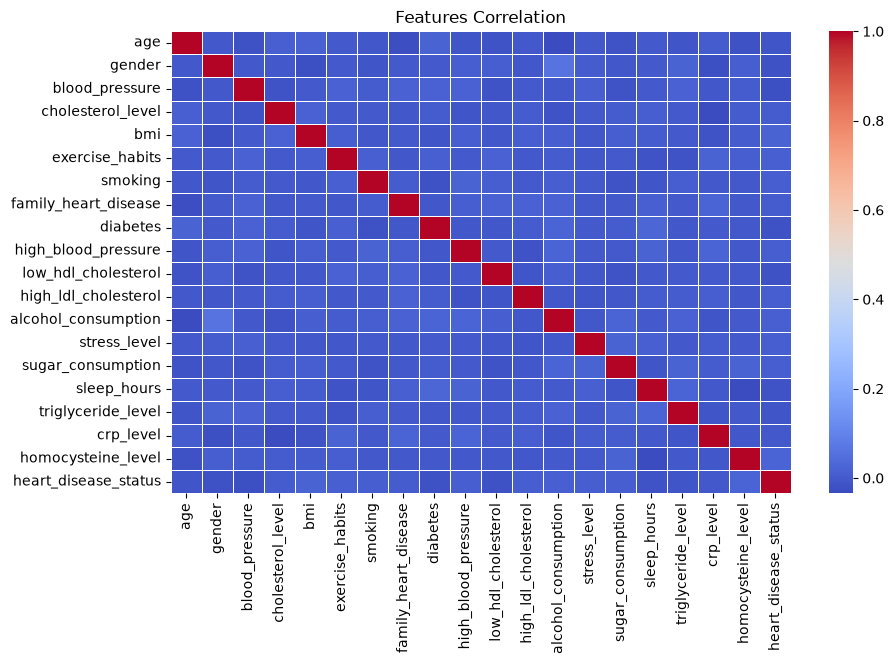

heart_disease_status    1.000000
blood_pressure         -0.022806
homocysteine_level      0.022456
low_hdl_cholesterol    -0.021918
gender                 -0.020399
diabetes               -0.018933
bmi                     0.018709
sleep_hours            -0.014373
exercise_habits         0.014291
alcohol_consumption     0.013171
age                    -0.012535
triglyceride_level     -0.010110
smoking                 0.009406
sugar_consumption       0.008266
high_ldl_cholesterol    0.007767
stress_level            0.007653
high_blood_pressure     0.006420
crp_level              -0.005310
cholesterol_level       0.003864
family_heart_disease    0.003506
Name: heart_disease_status, dtype: float64


In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False ,cmap='coolwarm',linewidths=0.5)
plt.title('Features Correlation')
plt.show()

print(df.corr()['heart_disease_status'].sort_values(key=abs, ascending=False))

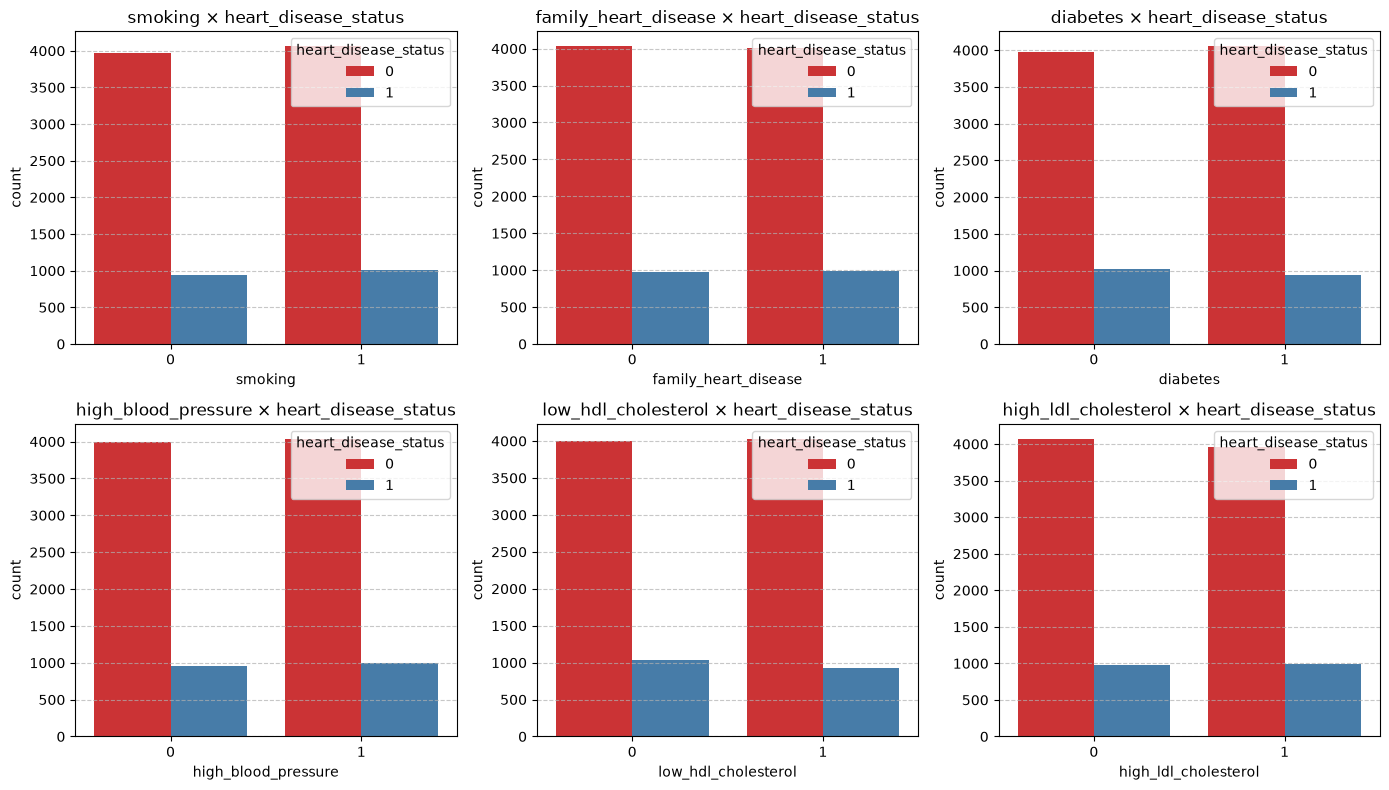

In [6]:
binary_cols = [
    'smoking', 'family_heart_disease', 'diabetes',
    'high_blood_pressure', 'low_hdl_cholesterol', 'high_ldl_cholesterol'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, hue='heart_disease_status', data=df,
                  palette='Set1', ax=axes[i])
    axes[i].set_title(f'{col} × heart_disease_status')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import  classification_report
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# df_main training for main data
x = df_main.drop(columns='heart_disease_status')
y = df_main['heart_disease_status']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

scalar = StandardScaler()

x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)

sgd.partial_fit(x_train_scaled, y_train ,classes=np.array([0, 1]))

y_pred = sgd.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(sgd, x, y, cv=5, scoring='f1_macro')

print(f"5-Fold CV F1 Macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

              precision    recall  f1-score   support

           0       0.81      0.93      0.86       802
           1       0.28      0.12      0.16       198

    accuracy                           0.77      1000
   macro avg       0.54      0.52      0.51      1000
weighted avg       0.70      0.77      0.72      1000

5-Fold CV F1 Macro: 0.391 ± 0.111


_5-Fold CV means the model was trained and tested five separate times on different chunks of data._

_F1 Macro indicates the evaluation metric used treats all data categories equally, regardless of how many examples exist for each._

_0.391 is  average score out of a possible 1.0, which generally suggests poor predictive performance._

_± 0.111 is the standard deviation, meaning your model's accuracy fluctuated significantly depending on which chunk of data it tested._

_This result as a whole tells you the model is currently inaccurate and unstable, likely needing better dataset or a different algorithm._

In [8]:
# df_p1 | training for new input 1

p1xtrain_scaled = scalar.transform(df_p1.drop(columns='heart_disease_status'))
p1ytrain = df_p1['heart_disease_status']
sgd.partial_fit(p1xtrain_scaled,p1ytrain,classes=np.array([0, 1]))
y_pred = sgd.predict(x_test_scaled)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.86      0.83       802
           1       0.20      0.14      0.16       198

    accuracy                           0.72      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.68      0.72      0.70      1000



In [9]:
# df_p2 | training for new input 2

p1xtrain2_scaled = scalar.transform(df_p2.drop(columns='heart_disease_status'))
p1ytrain2 = df_p2['heart_disease_status']
sgd.partial_fit(p1xtrain2_scaled,p1ytrain2,classes=np.array([0, 1]))
y_pred = sgd.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.82       802
           1       0.22      0.17      0.19       198

    accuracy                           0.71      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.69      0.71      0.70      1000



/tmp/ipykernel_671030/2408464605.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')


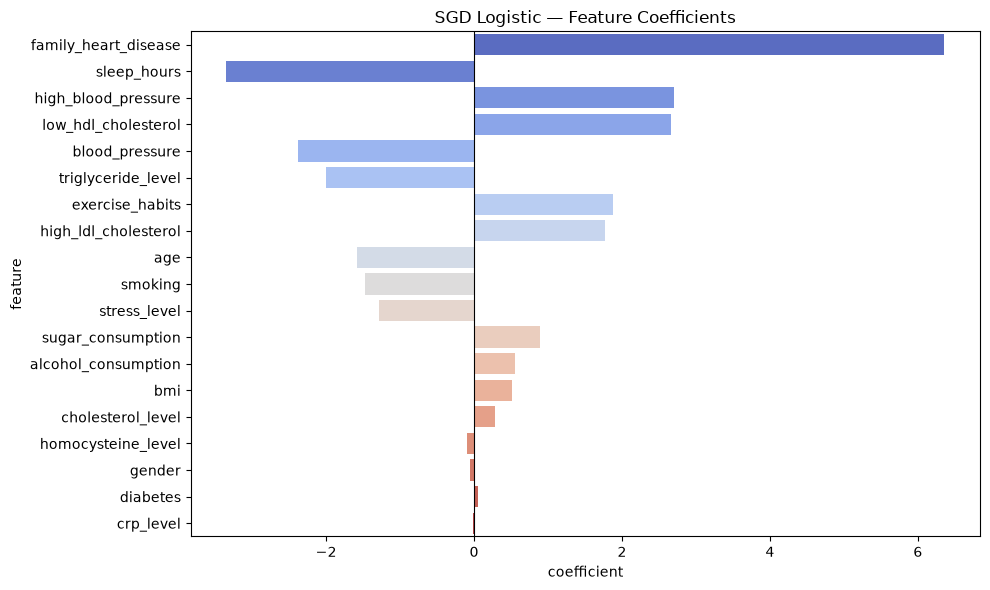

In [10]:
coef_df = pd.DataFrame({
    'feature': x_train.columns,
    'coefficient': sgd.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')
plt.title('SGD Logistic — Feature Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

_Magnitude (Length of the bar): The further a bar stretches away from the center zero line (either left or right), the more important that feature is to the model's decision-making. Features near the zero line are essentially being ignored by the model._

_Direction (Left vs. Right of zero):_

_Positive Coefficients (Right): Higher values in these features push the model to predict the "positive" class (usually class 1)._

_Negative Coefficients (Left): Higher values in these features push the model to predict the "negative" class (usually class 0)._